<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter3/pendulum_detachment_trajectories.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Trajectories of the detached pendulum CM and rotation about the CM

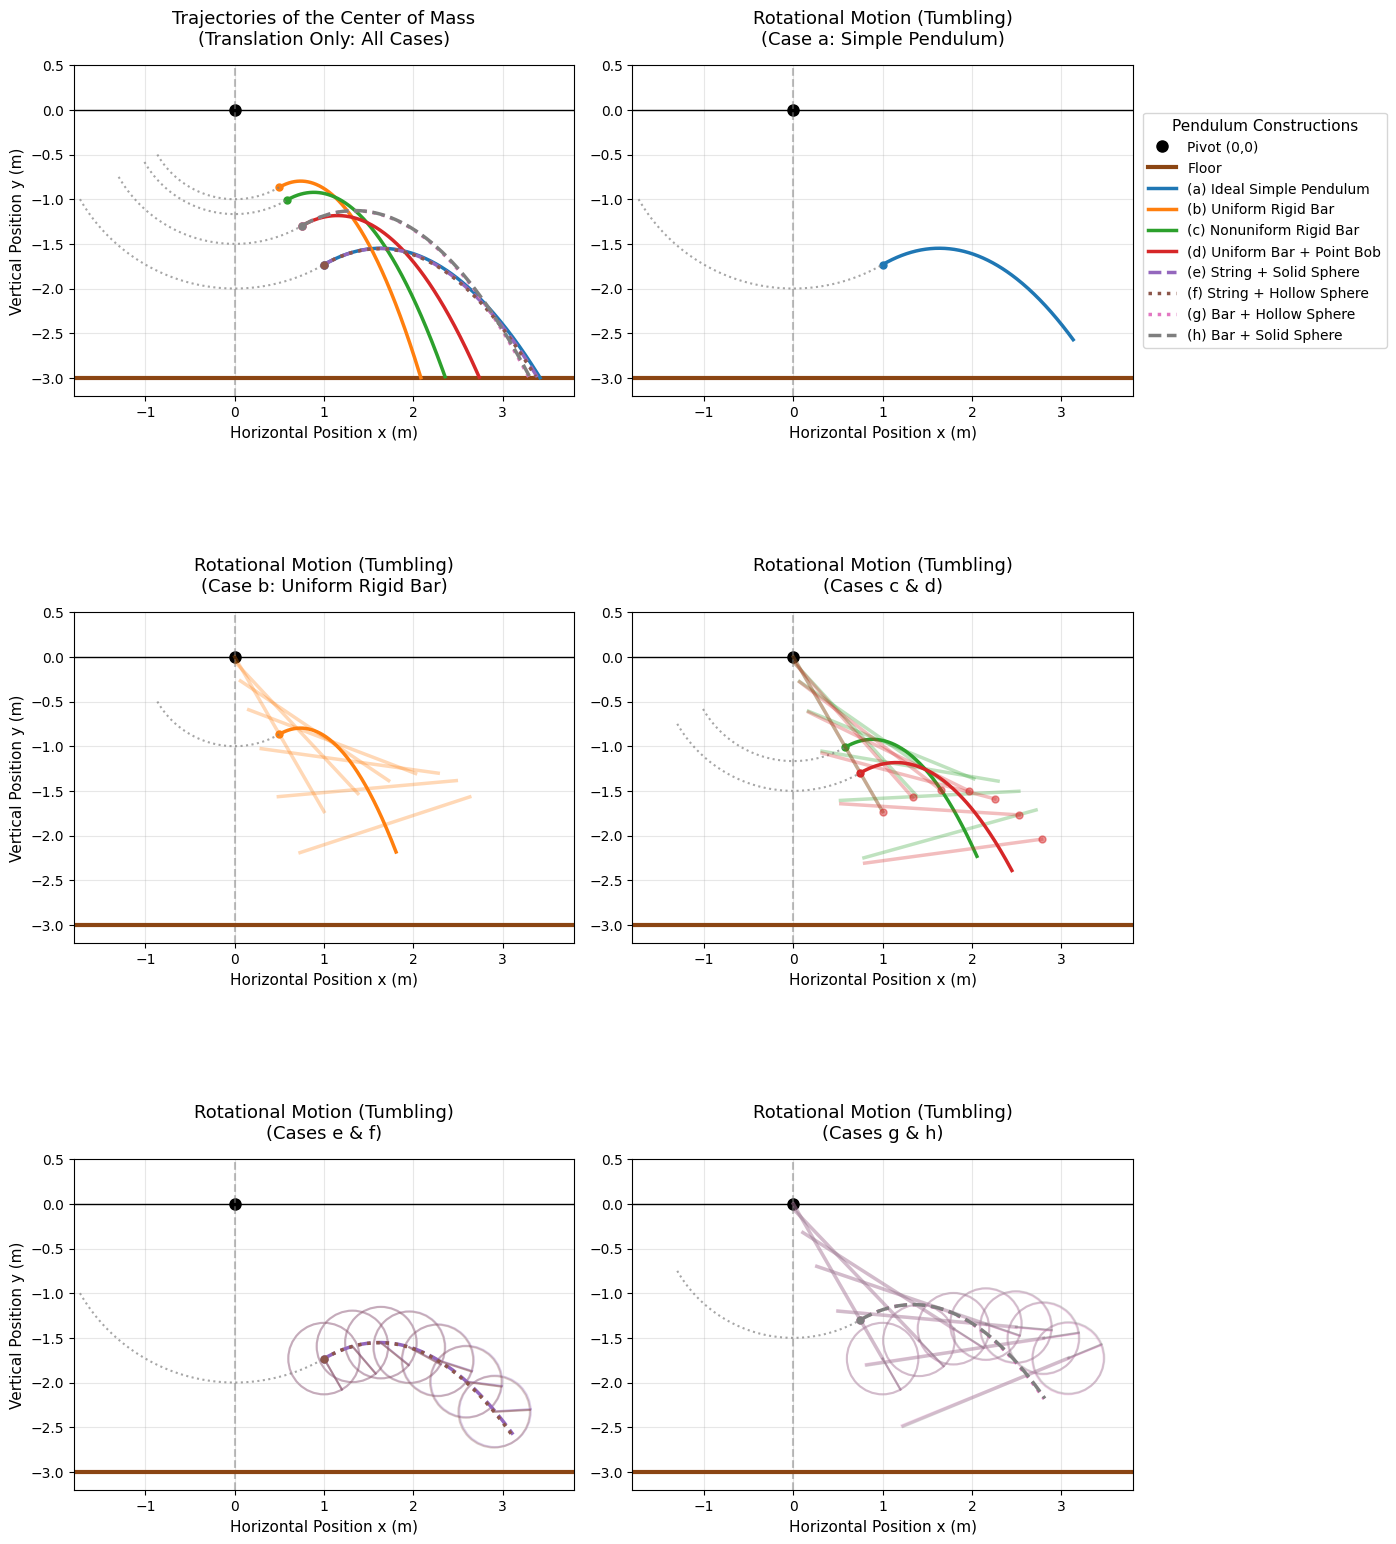

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Physical Parameters & Setup
# ==========================================
g = 9.81        # Gravity (m/s^2)
l = 2.0         # Length of pendulum string/rod (m)
R = 0.4         # Radius of the spherical bobs (m)

# Release from -60 degrees (left side), detach at +30 degrees (right side)
# This simulates a swing through the bottom.
theta_0 = np.radians(-60)
theta_f = np.radians(30)

# Delta Cosine term used in all velocity equations
# (Note: cos(-60) = cos(60), so this correctly evaluates the energy difference)
delta_cos = np.cos(theta_f) - np.cos(theta_0)

# Time arrays for the free-flight projectile motion
t_short = np.linspace(0, 0.65, 200)
t_long = np.linspace(0, 1.2, 400) # Extended time to ensure it reaches the floor

# ==========================================
# 2. Case Definitions (from the Comprehensive Theory)
# ==========================================
# Format: 'Label': (r_cm, v_cm, color, style, shape_type)

cases = {}

# (a) Ideal Simple Pendulum (Point Mass)
cases['(a) Ideal Simple Pendulum'] = (l, np.sqrt(2 * g * l * delta_cos), '#1f77b4', '-', 'point')

# (b) Uniform Rigid Bar
cases['(b) Uniform Rigid Bar'] = (0.5 * l, 0.5 * np.sqrt(3 * g * l * delta_cos), '#ff7f0e', '-', 'bar')

# (c) Nonuniform Rigid Bar (r_cm = 7/12 l, I_pivot = 5/12 ml^2)
v_cm_c = (7/12) * l * np.sqrt((14 * g) / (5 * l) * delta_cos)
cases['(c) Nonuniform Rigid Bar'] = ((7/12) * l, v_cm_c, '#2ca02c', '-', 'bar')

# (d) Uniform Bar + Point Bob
cases['(d) Uniform Bar + Point Bob'] = (0.75 * l, (9/8) * np.sqrt(g * l * delta_cos), '#d62728', '-', 'bar_point')

# (e) String + Solid Sphere
cases['(e) String + Solid Sphere'] = (l, l * np.sqrt((2 * g * l) / (l**2 + 0.4 * R**2) * delta_cos), '#9467bd', '--', 'sphere')

# (f) String + Hollow Sphere
cases['(f) String + Hollow Sphere'] = (l, l * np.sqrt((2 * g * l) / (l**2 + (2/3) * R**2) * delta_cos), '#8c564b', ':', 'sphere')

# (g) Bar + Hollow Sphere
cases['(g) Bar + Hollow Sphere'] = (0.75 * l, (9/8) * l * np.sqrt((g * l) / ((2/3)*l**2 + (1/3)*R**2) * delta_cos), '#e377c2', ':', 'bar_sphere')

# (h) Bar + Solid Sphere
cases['(h) Bar + Solid Sphere'] = (0.75 * l, (9/8) * l * np.sqrt((g * l) / ((2/3)*l**2 + (1/5)*R**2) * delta_cos), '#7f7f7f', '--', 'bar_sphere')


# ==========================================
# 3. Plotting Logic
# ==========================================
# Create a figure with a 3x2 grid of subplots for better visual clarity
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
floor_y = -l - 1.0

# Configure what each subplot will show: (Axis, ShowSpin, Title, TargetCases)
plot_configs = [
    (axes[0, 0], False, "Trajectories of the Center of Mass\n(Translation Only: All Cases)", list(cases.keys())),
    (axes[0, 1], True,  "Rotational Motion (Tumbling)\n(Case a: Simple Pendulum)", ['(a) Ideal Simple Pendulum']),
    (axes[1, 0], True,  "Rotational Motion (Tumbling)\n(Case b: Uniform Rigid Bar)", ['(b) Uniform Rigid Bar']),
    (axes[1, 1], True,  "Rotational Motion (Tumbling)\n(Cases c & d)", ['(c) Nonuniform Rigid Bar', '(d) Uniform Bar + Point Bob']),
    (axes[2, 0], True,  "Rotational Motion (Tumbling)\n(Cases e & f)", ['(e) String + Solid Sphere', '(f) String + Hollow Sphere']),
    (axes[2, 1], True,  "Rotational Motion (Tumbling)\n(Cases g & h)", ['(g) Bar + Hollow Sphere', '(h) Bar + Solid Sphere'])
]

for ax, show_spin, title, target_cases in plot_configs:
    # Determine which time array to use (only the first plot uses the extended time)
    current_t = t_long if ax == axes[0, 0] else t_short

    # Draw the pivot and reference lines
    ax.plot(0, 0, 'ko', markersize=8, label='Pivot (0,0)')
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(floor_y, color='saddlebrown', linewidth=3, label='Floor')

    # Keep track of which CM radii we've drawn swing arcs for on this specific axis
    drawn_arcs = set()

    # Iterate through all the cases and plot them
    for label, (r_cm, v_cm, color, style, shape) in cases.items():
        # Skip plotting if the case isn't assigned to this subplot
        if label not in target_cases:
            continue

        # Calculate starting coordinates at detachment
        x0 = r_cm * np.sin(theta_f)
        y0 = -r_cm * np.cos(theta_f)

        # Calculate initial velocity components
        vx0 = v_cm * np.cos(theta_f)
        vy0 = v_cm * np.sin(theta_f)

        # Generate the trajectory
        x = x0 + vx0 * current_t
        y = y0 + vy0 * current_t - 0.5 * g * current_t**2

        # Filter the arrays so we don't plot below the floor
        valid_idx = y >= floor_y
        x = x[valid_idx]
        y = y[valid_idx]
        t_valid = current_t[valid_idx]

        # Plot the free-flight trajectory
        ax.plot(x, y, color=color, linestyle=style, linewidth=2.5, label=label)

        # Mark the exact detachment point
        ax.plot(x0, y0, marker='o', color=color, markersize=5)

        # Plot the rotation snapshots if enabled for this axis
        if show_spin:
            omega_f = v_cm / r_cm

            # Draw a snapshot every 30 time steps
            for i in range(0, len(x), 30):
                xi, yi, ti = x[i], y[i], t_valid[i]
                phi = theta_f + omega_f * ti

                # Direction vector of the rod (from pivot pointing down to bob)
                dx = np.sin(phi)
                dy = -np.cos(phi)

                if shape in ['bar', 'bar_point', 'bar_sphere']:
                    # Draw the rigid bar
                    top_x = xi - r_cm * dx
                    top_y = yi - r_cm * dy
                    bot_x = xi + (l - r_cm) * dx
                    bot_y = yi + (l - r_cm) * dy
                    ax.plot([top_x, bot_x], [top_y, bot_y], color=color, alpha=0.3, linewidth=2.5)

                    if shape == 'bar_point':
                        ax.plot(bot_x, bot_y, marker='o', color=color, alpha=0.5, markersize=5)
                    elif shape == 'bar_sphere':
                        circle = plt.Circle((bot_x, bot_y), R, color=color, alpha=0.3, fill=False, linewidth=1.5)
                        ax.add_patch(circle)
                        # Radial line to show sphere rotation
                        ax.plot([bot_x, bot_x + R*np.sin(phi)], [bot_y, bot_y - R*np.cos(phi)], color=color, alpha=0.5, linewidth=1.5)

                elif shape == 'sphere':
                    # String goes slack, so we just draw the spinning sphere at the CM
                    circle = plt.Circle((xi, yi), R, color=color, alpha=0.3, fill=False, linewidth=1.5)
                    ax.add_patch(circle)
                    # Radial line to show it is rotating
                    ax.plot([xi, xi + R*np.sin(phi)], [yi, yi - R*np.cos(phi)], color=color, alpha=0.5, linewidth=1.5)

        # Draw the pre-detachment swing arc (only once per r_cm grouping)
        if r_cm not in drawn_arcs:
            arc_angles = np.linspace(theta_0, theta_f, 50)
            arc_x = r_cm * np.sin(arc_angles)
            arc_y = -r_cm * np.cos(arc_angles)
            ax.plot(arc_x, arc_y, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
            drawn_arcs.add(r_cm)

    # Formatting and Labels for the current axis
    ax.set_aspect('equal', adjustable='box') # Keep the geometry to scale!
    ax.set_xlim(-l*0.9, l*1.9)
    ax.set_ylim(floor_y - 0.2, 0.5)
    ax.set_title(title, fontsize=13, pad=15)
    ax.set_xlabel("Horizontal Position x (m)", fontsize=11)

    # Only label the y-axis for the leftmost plots in the grid
    if ax in [axes[0, 0], axes[1, 0], axes[2, 0]]:
        ax.set_ylabel("Vertical Position y (m)", fontsize=11)

    ax.grid(True, alpha=0.3)

# ==========================================
# 4. Global Formatting and Legend
# ==========================================
# Get the handles and labels from axes[0,0] (which has all lines) to create a unified global legend
handles, labels = axes[0, 0].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))

# Create a clean, grouped legend attached to the right side of the bottom-right subplot
axes[0, 1].legend(unique_labels.values(), unique_labels.keys(), loc='center left', fontsize=10,
           title="Pendulum Constructions", title_fontsize=11, bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

# Use tight_layout but leave space at the bottom for the caption and on the right for the legend
plt.tight_layout(rect=[0, 0.08, 0.88, 1])

# Render the plot
plt.show()